In [80]:
import random
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

In [81]:
df = pd.read_csv("../data/cleaned_dataset.csv", index_col=0)

In [82]:
df.columns

Index(['site_name', 'delivery_time', 'production', 'installed_capacity',
       'utilization_rate', 'wind_speed_10m', 'wind_speed_100m',
       'wind_gusts_10m', 'temperature_2m', 'dewpoint_2m',
       'apparent_temperature', 'pressure_msl', 'surface_pressure',
       'precipitation', 'snowfall', 'cloud_cover', 'cloud_cover_low',
       'cloud_cover_mid', 'cloud_cover_high', 'shortwave_radiation',
       'direct_radiation', 'diffuse_radiation', 'weather_code',
       'sunshine_duration', 'wind_speed_100m_cube', 'wind_shear',
       'wind_dir_100m_sin', 'wind_dir_100m_cos', 'hour_sin', 'hour_cos',
       'month_sin', 'month_cos', 'site_Belwind Phase 1',
       'site_Mermaid Offshore WP', 'site_Nobelwind Offshore Windpark',
       'site_Norther Offshore WP', 'site_Northwester 2', 'site_Northwind',
       'site_Rentel Offshore WP', 'site_Seastar Offshore WP',
       'site_Thorntonbank - C-Power - Area NE',
       'site_Thorntonbank - C-Power - Area SW', 'is_maintenance',
       'maint_rol

In [83]:
df.head()

,site_name,delivery_time,production,installed_capacity,utilization_rate,wind_speed_10m,wind_speed_100m,wind_gusts_10m,temperature_2m,dewpoint_2m,...,site_Northwind,site_Rentel Offshore WP,site_Seastar Offshore WP,site_Thorntonbank - C-Power - Area NE,site_Thorntonbank - C-Power - Area SW,is_maintenance,maint_rolling_sum,is_confirmed_maint,is_curtailment,to_drop_for_training
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
0,Belwind Phase 1,2023-01-01 00:00:00+00:00,147.7025,171.0,0.863757,14.603082,19.897738,20.7,12.25,8.85,...,False,False,False,False,False,0,NaN,0,0,False
1,Belwind Phase 1,2023-01-01 01:00:00+00:00,146.1775,171.0,0.854839,16.182089,21.681328,20.8,12.10,8.80,...,False,False,False,False,False,0,0.0,0,0,False
2,Belwind Phase 1,2023-01-01 02:00:00+00:00,146.1800,171.0,0.854854,17.969420,23.809662,24.1,11.85,9.50,...,False,False,False,False,False,0,0.0,0,0,False
3,Belwind Phase 1,2023-01-01 03:00:00+00:00,146.5050,171.0,0.856754,14.792228,19.860010,23.9,11.80,9.85,...,False,False,False,False,False,0,0.0,0,0,False
4,Belwind Phase 1,2023-01-01 04:00:00+00:00,146.6950,171.0,0.857865,15.001333,19.915070,19.7,11.75,9.30,...,False,False,False,False,False,0,0.0,0,0,False


In [84]:
def add_lag_rolling_features(df, target_col='utilization_rate'):
    """
    Ajoute LAG et ROLLING features sur les colonnes existantes,
    en s'assurant de ne pas utiliser de données à moins de 12h.
    """
    df = df.copy()
    df['delivery_time'] = pd.to_datetime(df['delivery_time'])
    
    # Création des lags de base
    for lag in [12, 24, 36]:
        df[f'{target_col}_lag_{lag}h'] = df.groupby('site_name')[target_col].shift(lag)
        df[f'wind_100m_lag_{lag}h'] = df.groupby('site_name')['wind_speed_100m'].shift(lag)
    
    # Moyennes et écart-types glissants appliqués sur la donnée décalée de 12h
    for window in [12, 24]:
        # On décale d'abord de 12h (`.shift(12)`), puis on calcule la rolling window
        df[f'{target_col}_rolling_mean_{window}h_lag12'] = df.groupby('site_name')[target_col].transform(
            lambda x: x.shift(12).rolling(window=window, min_periods=1).mean()
        )
        
        df[f'{target_col}_rolling_std_{window}h_lag12'] = df.groupby('site_name')[target_col].transform(
            lambda x: x.shift(12).rolling(window=window, min_periods=1).std()
        )
        
        df[f'wind_100m_rolling_mean_{window}h_lag12'] = df.groupby('site_name')['wind_speed_100m'].transform(
            lambda x: x.shift(12).rolling(window=window, min_periods=1).mean()
        )

        df[f'temp_rolling_mean_{window}h_lag12'] = df.groupby('site_name')['temperature_2m'].transform(
            lambda x: x.shift(12).rolling(window=window, min_periods=1).mean()
        )
        
        df[f'radiation_rolling_mean_{window}h_lag12'] = df.groupby('site_name')['shortwave_radiation'].transform(
            lambda x: x.shift(12).rolling(window=window, min_periods=1).mean()
        )
    
    # Évolution de la production (tendances) calculées uniquement avec des données >= 12h
    df[f'{target_col}_change_12h_24h'] = df[f'{target_col}_lag_12h'] - df[f'{target_col}_lag_24h']
    df[f'{target_col}_change_24h_36h'] = df[f'{target_col}_lag_24h'] - df[f'{target_col}_lag_36h']
    
    df['wind_change_12h_24h'] = df['wind_100m_lag_12h'] - df['wind_100m_lag_24h']
    
    df['day_of_week'] = df['delivery_time'].dt.dayofweek
    df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
    
    return df

df_featured = add_lag_rolling_features(df, target_col='utilization_rate')

print(f"Colonnes avant : {len(df.columns)}")
print(f"Colonnes après : {len(df_featured.columns)}")
print(f"\nNouvelles colonnes ajoutées : {len(df_featured.columns) - len(df.columns)}")
print(f"NaN introduits : {df_featured.isnull().sum().sum()}")

Colonnes avant : 47
Colonnes après : 68

Nouvelles colonnes ajoutées : 21
NaN introduits : 3520


In [85]:
df_featured['utilization_rate_24h'] = df_featured.groupby('site_name')['utilization_rate'].shift(-24)

In [86]:
df['utilization_rate']

Unnamed: 0
0         0.863757
1         0.854839
2         0.854854
3         0.856754
4         0.857865
            ...   
274785    0.979012
274786    0.980771
274787    0.905251
274788    0.878209
274789    0.916118
Name: utilization_rate, Length: 229569, dtype: float64

On rajoute les données du forecast pendant la période de la prédiction:

In [87]:
df_featured.columns

Index(['site_name', 'delivery_time', 'production', 'installed_capacity',
       'utilization_rate', 'wind_speed_10m', 'wind_speed_100m',
       'wind_gusts_10m', 'temperature_2m', 'dewpoint_2m',
       'apparent_temperature', 'pressure_msl', 'surface_pressure',
       'precipitation', 'snowfall', 'cloud_cover', 'cloud_cover_low',
       'cloud_cover_mid', 'cloud_cover_high', 'shortwave_radiation',
       'direct_radiation', 'diffuse_radiation', 'weather_code',
       'sunshine_duration', 'wind_speed_100m_cube', 'wind_shear',
       'wind_dir_100m_sin', 'wind_dir_100m_cos', 'hour_sin', 'hour_cos',
       'month_sin', 'month_cos', 'site_Belwind Phase 1',
       'site_Mermaid Offshore WP', 'site_Nobelwind Offshore Windpark',
       'site_Norther Offshore WP', 'site_Northwester 2', 'site_Northwind',
       'site_Rentel Offshore WP', 'site_Seastar Offshore WP',
       'site_Thorntonbank - C-Power - Area NE',
       'site_Thorntonbank - C-Power - Area SW', 'is_maintenance',
       'maint_rol

In [88]:
weather_cols = [
    'wind_speed_10m', 'wind_speed_100m', 'wind_gusts_10m',
    'temperature_2m', 'dewpoint_2m', 'apparent_temperature',
    'pressure_msl', 'surface_pressure', 'precipitation', 'snowfall',
    'cloud_cover', 'cloud_cover_low', 'cloud_cover_mid', 'cloud_cover_high',
    'shortwave_radiation', 'direct_radiation', 'diffuse_radiation',
    'sunshine_duration', 'wind_speed_100m_cube', 'wind_shear',
    'wind_dir_100m_sin', 'wind_dir_100m_cos'
]

for col in weather_cols:
    if col in df_featured.columns and f'{col}_24h_ahead' not in df_featured.columns:
        df_featured[f'{col}_24h_ahead'] = df_featured.groupby('site_name')[col].shift(-24)

In [89]:
df_model = df_featured.dropna().copy()
df_model = df_model[df_model['to_drop_for_training'] != 1]
df_model = df_model.sort_values('delivery_time').reset_index(drop=True)

print(f"Lignes conservées : {len(df_model)}/{len(df_featured)}")

features_to_exclude = [
    'site_name', 'delivery_time', 'production', 'to_drop_for_training',
    'utilization_rate_24h', 'utilization_rate'
] + weather_cols

X = df_model.drop(columns=features_to_exclude)
y = df_model['utilization_rate_24h']

print(f"\nFeatures sélectionnées : {X.shape[1]}")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

print(f"\nData types:\n{X.dtypes.value_counts()}")

Lignes conservées : 228969/229569

Features sélectionnées : 63
X shape: (228969, 63)
y shape: (228969,)

Data types:
float64    48
bool       10
int64       4
int32       1
Name: count, dtype: int64


In [90]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, 
    test_size=0.3,
    shuffle=False
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    shuffle=False
)

print(f"\nTrain size: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f"Val size:   {len(X_val)} ({len(X_val)/len(X)*100:.1f}%)")
print(f"Test size:  {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")


feature_cols = [col for col in df_model.columns if col not in features_to_exclude]

print(f"\nFeatures sélectionnées: {len(feature_cols)}")
print(f"X_train: {X_train.shape} | y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape}   | y_val:   {y_val.shape}")
print(f"X_test:  {X_test.shape}   | y_test:  {y_test.shape}")


Train size: 160278 (70.0%)
Val size:   34345 (15.0%)
Test size:  34346 (15.0%)

Features sélectionnées: 63
X_train: (160278, 63) | y_train: (160278,)
X_val:   (34345, 63)   | y_val:   (34345,)
X_test:  (34346, 63)   | y_test:  (34346,)


In [91]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [92]:
model = xgb.XGBRegressor(
    n_estimators=200,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=1,
    early_stopping_rounds=20,
    eval_metric='rmse'
)

model.fit(
    X_train_scaled, y_train,
    eval_set=[(X_val_scaled, y_val)], # Evaluation sur le set de validation
    verbose=10
)

[0]	validation_0-rmse:0.29426
[10]	validation_0-rmse:0.15163
[20]	validation_0-rmse:0.12032
[30]	validation_0-rmse:0.11459
[40]	validation_0-rmse:0.11351
[50]	validation_0-rmse:0.11337
[60]	validation_0-rmse:0.11321
[70]	validation_0-rmse:0.11338
[77]	validation_0-rmse:0.11323


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,20
,enable_categorical,False
,eval_metric,'rmse'


In [93]:
y_train_pred = model.predict(X_train_scaled)
y_val_pred = model.predict(X_val_scaled)
y_test_pred = model.predict(X_test_scaled)

In [94]:
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_mae = mean_absolute_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

print(f"\nTrain set:")
print(f"  RMSE: {train_rmse:.4f}")
print(f"  MAE:  {train_mae:.4f}")
print(f"  R²:   {train_r2:.4f}")


Train set:
  RMSE: 0.0855
  MAE:  0.0582
  R²:   0.9379


In [95]:
val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
val_mae = mean_absolute_error(y_val, y_val_pred)
val_r2 = r2_score(y_val, y_val_pred)

print(f"\nValidation set:")
print(f"  RMSE: {val_rmse:.4f}")
print(f"  MAE:  {val_mae:.4f}")
print(f"  R²:   {val_r2:.4f}")



Validation set:
  RMSE: 0.1132
  MAE:  0.0758
  R²:   0.8619


In [96]:
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_mae = mean_absolute_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)

print(f"\nTest set:")
print(f"  RMSE: {test_rmse:.4f}")
print(f"  MAE:  {test_mae:.4f}")
print(f"  R²:   {test_r2:.4f}")


Test set:
  RMSE: 0.1152
  MAE:  0.0835
  R²:   0.8881


In [97]:
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print(feature_importance.head(20).to_string())


                                  feature  importance
42              wind_speed_100m_24h_ahead    0.483472
59         wind_speed_100m_cube_24h_ahead    0.278729
41               wind_speed_10m_24h_ahead    0.058770
43               wind_gusts_10m_24h_ahead    0.025827
10                     site_Northwester 2    0.014955
8        site_Nobelwind Offshore Windpark    0.012167
11                         site_Northwind    0.007995
6                    site_Belwind Phase 1    0.007027
0                      installed_capacity    0.006911
61            wind_dir_100m_sin_24h_ahead    0.004723
14  site_Thorntonbank - C-Power - Area NE    0.004572
7                site_Mermaid Offshore WP    0.004052
15  site_Thorntonbank - C-Power - Area SW    0.003991
62            wind_dir_100m_cos_24h_ahead    0.003988
9                site_Norther Offshore WP    0.003857
5                               month_cos    0.003813
60                   wind_shear_24h_ahead    0.003190
56             direct_radiat

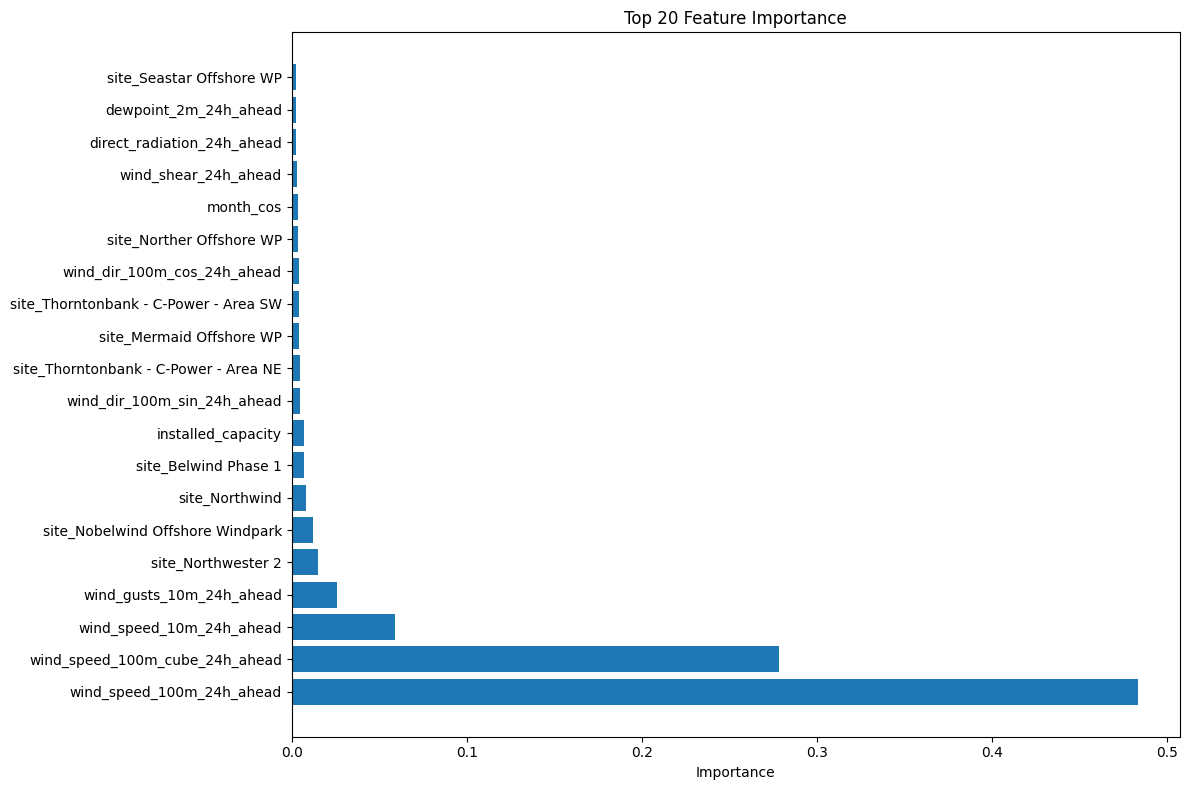

In [98]:
plt.figure(figsize=(12, 8))
top_features = feature_importance.head(20)
plt.barh(range(len(top_features)), top_features['importance'])
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Importance')
plt.title('Top 20 Feature Importance')
plt.tight_layout()
plt.show()

In [99]:
SEQ_LEN = 24

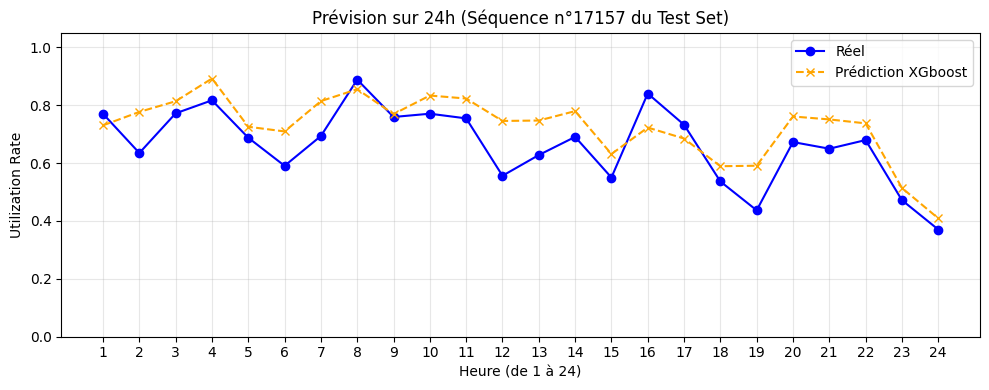

In [100]:
idx_start = random.randint(0, len(y_test) - SEQ_LEN)

vraie_sequence = y_test.iloc[idx_start : idx_start + SEQ_LEN].values
sequence_predite = y_test_pred[idx_start : idx_start + SEQ_LEN]
heures = np.arange(1, SEQ_LEN + 1)

plt.figure(figsize=(10, 4))
plt.plot(heures, vraie_sequence, label="Réel", color='blue', marker='o')
plt.plot(heures, sequence_predite, label="Prédiction XGboost", color='orange', marker='x', linestyle='--')

plt.title(f"Prévision sur 24h (Séquence n°{idx_start} du Test Set)")
plt.xlabel("Heure (de 1 à 24)")
plt.ylabel("Utilization Rate")
plt.ylim(0, 1.05)
plt.xticks(heures)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()